<a href="https://colab.research.google.com/github/Cicel599/patient-appointment-no-show-prediction/blob/main/Notebooks/Notebook_04_Fairness_Audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Patient Appointment No-Show Prediction
## Notebook 04 — Demographic Fairness Audit
### COM748 MSc Research Project — Ulster University

**Reference:** Obermeyer et al. (2019) — clinical ML algorithms can embed demographic bias  
**Model audited:** XGBoost (best performing model from Notebook 02)

---
### Why a Fairness Audit?
Obermeyer et al. (2019) demonstrated that a widely deployed clinical algorithm embedded substantial racial bias, arising from a flawed proxy variable. This established that predictive accuracy alone is insufficient — demographic fairness must be explicitly evaluated.

A model that systematically misses no-shows for one demographic group means those patients receive fewer targeted interventions, potentially reinforcing existing healthcare inequalities.

### What We Measure
**False Negative Rate (FNR)** = proportion of actual no-shows the model FAILS to flag  
FNR = False Negatives / (False Negatives + True Positives)

A higher FNR for one group means the model is worse at catching no-shows for that group — the clinically critical error.

---
### Notebook Structure
1. Imports and setup
2. Load model, data, and cleaned dataset
3. Align test set with demographic metadata
4. Fairness audit — Age subgroups
5. Fairness audit — Gender subgroups
6. Fairness audit — Scholarship status
7. Combined fairness summary
8. Statistical significance testing
9. Key findings and dissertation conclusions

---
## 1. Imports and Setup

In [ ]:
# ── Install if on Colab ───────────────────────────────────────────────────
!pip install xgboost -q

import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import chi2_contingency, fisher_exact
from sklearn.metrics import confusion_matrix
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi'      : 150,
    'figure.facecolor': 'white',
    'axes.facecolor'  : 'white',
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'font.family'     : 'sans-serif',
    'font.size'       : 11
})

RANDOM_STATE = 42

print('=' * 60)
print('All libraries loaded successfully')
print('=' * 60)

All libraries loaded successfully


---
## 2. Load Model, Data, and Cleaned Dataset

In [ ]:
# ── Paths — update if using Google Drive ─────────────────────────────────
DATA_DIR   = 'data_processed'
MODELS_DIR = 'trained_models'

# ── Load model and test data ──────────────────────────────────────────────
xgb_model    = joblib.load(f'{MODELS_DIR}/xgboost.pkl')
X_test       = joblib.load(f'{DATA_DIR}/X_test.pkl')
y_test       = joblib.load(f'{DATA_DIR}/y_test.pkl')
FEATURE_COLS = joblib.load(f'{DATA_DIR}/feature_columns.pkl')

X_test_df  = pd.DataFrame(X_test, columns=FEATURE_COLS)
y_test_arr = np.array(y_test)

# ── Load cleaned dataset for demographic metadata ─────────────────────────
# The cleaned_dataset.csv contains the original demographic columns
# (age, gender, scholarship) aligned with the full cleaned dataset
df_clean = pd.read_csv(f'{DATA_DIR}/cleaned_dataset.csv')

print('=' * 60)
print('Data and Model Loaded')
print('=' * 60)
print(f'Test set shape     : {X_test_df.shape}')
print(f'Cleaned dataset    : {df_clean.shape}')
print(f'Test no-show rate  : {y_test_arr.mean()*100:.1f}%')

Data and Model Loaded
Test set shape     : (22105, 17)
Cleaned dataset    : (110521, 28)
Test no-show rate  : 20.2%


---
## 3. Align Test Set with Demographic Metadata

The test set was created by stratified 80/20 split in Notebook 01.
We need to recover the demographic columns (age, gender, scholarship)
for the exact records in the test set.

We do this by matching on the feature values already in X_test,
since age, gender_binary, and scholarship are all in the feature set.

In [ ]:
# ── Get model predictions on test set ────────────────────────────────────
y_pred = xgb_model.predict(X_test_df)
y_prob = xgb_model.predict_proba(X_test_df)[:, 1]

# ── Build audit dataframe ─────────────────────────────────────────────────
# age and gender_binary and scholarship are already in X_test_df
# y_test_arr = true labels, y_pred = predicted labels

audit_df = pd.DataFrame({
    'age'            : X_test_df['age'].values,
    'gender_binary'  : X_test_df['gender_binary'].values,
    'scholarship'    : X_test_df['scholarship'].values,
    'y_true'         : y_test_arr,
    'y_pred'         : y_pred,
    'y_prob'         : y_prob
})

# ── Age: note these are scaled values (MinMax 0-1)
# We need to reverse-scale age for interpretable subgroups
# Load scaler to reverse transform age
scaler = joblib.load(f'{DATA_DIR}/scaler.pkl')

# Get original age range from cleaned dataset
age_min = df_clean['age'].min()
age_max = df_clean['age'].max()

# Reverse MinMax scaling: original = scaled * (max - min) + min
audit_df['age_original'] = (audit_df['age'] * (age_max - age_min) + age_min).round().astype(int)

# ── Create age bands ──────────────────────────────────────────────────────
bins   = [0, 17, 35, 55, 115]
labels = ['0-17 (Child)', '18-35 (Young Adult)', '36-55 (Middle-Aged)', '56+ (Older Adult)']
audit_df['age_group'] = pd.cut(audit_df['age_original'], bins=bins, labels=labels, right=True)

# ── Gender label ──────────────────────────────────────────────────────────
audit_df['gender'] = audit_df['gender_binary'].map({1: 'Female', 0: 'Male'})

# ── Scholarship label ─────────────────────────────────────────────────────
audit_df['scholarship_label'] = audit_df['scholarship'].map({1: 'Scholarship (Low Income)', 0: 'No Scholarship'})

print('Audit dataframe created.')
print(f'Total test records  : {len(audit_df):,}')
print(f'Actual no-shows     : {audit_df["y_true"].sum():,} ({audit_df["y_true"].mean()*100:.1f}%)')
print(f'\nAge group distribution:')
print(audit_df['age_group'].value_counts().sort_index())
print(f'\nGender distribution:')
print(audit_df['gender'].value_counts())
print(f'\nScholarship distribution:')
print(audit_df['scholarship_label'].value_counts())

Audit dataframe created.
Total test records  : 22,105
Actual no-shows     : 4,463 (20.2%)

Age group distribution:
age_group
0-17 (Child)           4644
18-35 (Young Adult)    5173
36-55 (Middle-Aged)    6053
56+ (Older Adult)      5530
Name: count, dtype: int64

Gender distribution:
gender
Female    14415
Male       7690
Name: count, dtype: int64

Scholarship distribution:
scholarship_label
No Scholarship              19945
Scholarship (Low Income)     2160
Name: count, dtype: int64


In [ ]:
# ── Helper function: compute fairness metrics per group ───────────────────
def fairness_metrics(group_df):
    """
    Compute fairness metrics for a subgroup.
    Focus on False Negative Rate (FNR) — the clinically critical error.
    FNR = FN / (FN + TP) = proportion of actual no-shows MISSED by the model.
    """
    y_true = group_df['y_true'].values
    y_pred = group_df['y_pred'].values

    if y_true.sum() == 0:  # No actual no-shows in group
        return None

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    fnr  = fn / (fn + tp) if (fn + tp) > 0 else 0   # Miss rate — key metric
    fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0   # False alarm rate
    tpr  = tp / (tp + fn) if (tp + fn) > 0 else 0   # Recall / sensitivity
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0   # Precision

    return {
        'N (total)'     : len(group_df),
        'N (no-shows)'  : int(y_true.sum()),
        'No-show rate'  : round(y_true.mean() * 100, 1),
        'FNR (miss rate)': round(fnr, 4),
        'FPR'           : round(fpr, 4),
        'Recall (TPR)'  : round(tpr, 4),
        'Precision'     : round(prec, 4),
        'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn)
    }

print('Fairness metrics function defined.')
print('Key metric: False Negative Rate (FNR) — proportion of actual no-shows missed.')
print('Higher FNR = model systematically fails this group = potential bias.')

Fairness metrics function defined.
Key metric: False Negative Rate (FNR) — proportion of actual no-shows missed.
Higher FNR = model systematically fails this group = potential bias.


---
## 4. Fairness Audit — Age Subgroups

Following Obermeyer et al. (2019): does the model perform equally across age groups?

In [ ]:
# ── Age group fairness metrics ─────────────────────────────────────────────
age_results = {}
for group in labels:
    subset = audit_df[audit_df['age_group'] == group]
    metrics = fairness_metrics(subset)
    if metrics:
        age_results[group] = metrics

age_df = pd.DataFrame(age_results).T

print('=' * 65)
print('FAIRNESS AUDIT — AGE SUBGROUPS')
print('=' * 65)
print(age_df[['N (total)', 'N (no-shows)', 'No-show rate',
              'FNR (miss rate)', 'Recall (TPR)', 'Precision']].to_string())

# Identify highest and lowest FNR groups
fnr_series = age_df['FNR (miss rate)'].astype(float)
best_group  = fnr_series.idxmin()
worst_group = fnr_series.idxmax()
fnr_gap     = fnr_series.max() - fnr_series.min()

print(f'\nLowest FNR (best protected)  : {best_group} — FNR = {fnr_series.min():.4f}')
print(f'Highest FNR (most missed)    : {worst_group} — FNR = {fnr_series.max():.4f}')
print(f'FNR gap between groups       : {fnr_gap:.4f}')

if fnr_gap > 0.10:
    print('CONCERN: FNR gap > 10 percentage points — potential demographic bias.')
elif fnr_gap > 0.05:
    print('NOTE: FNR gap 5-10 percentage points — moderate disparity, warrants monitoring.')
else:
    print('ACCEPTABLE: FNR gap < 5 percentage points — model performs consistently across age groups.')

FAIRNESS AUDIT — AGE SUBGROUPS
                     N (total)  N (no-shows)  No-show rate  FNR (miss rate)  Recall (TPR)  Precision
0-17 (Child)            4644.0        1015.0          21.9           0.5369        0.4631     0.4189
18-35 (Young Adult)     5173.0        1236.0          23.9           0.4992        0.5008     0.4067
36-55 (Middle-Aged)     6053.0        1189.0          19.6           0.7267        0.2733     0.3579
56+ (Older Adult)       5530.0         896.0          16.2           0.9152        0.0848     0.4524

Lowest FNR (best protected)  : 18-35 (Young Adult) — FNR = 0.4992
Highest FNR (most missed)    : 56+ (Older Adult) — FNR = 0.9152
FNR gap between groups       : 0.4160
CONCERN: FNR gap > 10 percentage points — potential demographic bias.


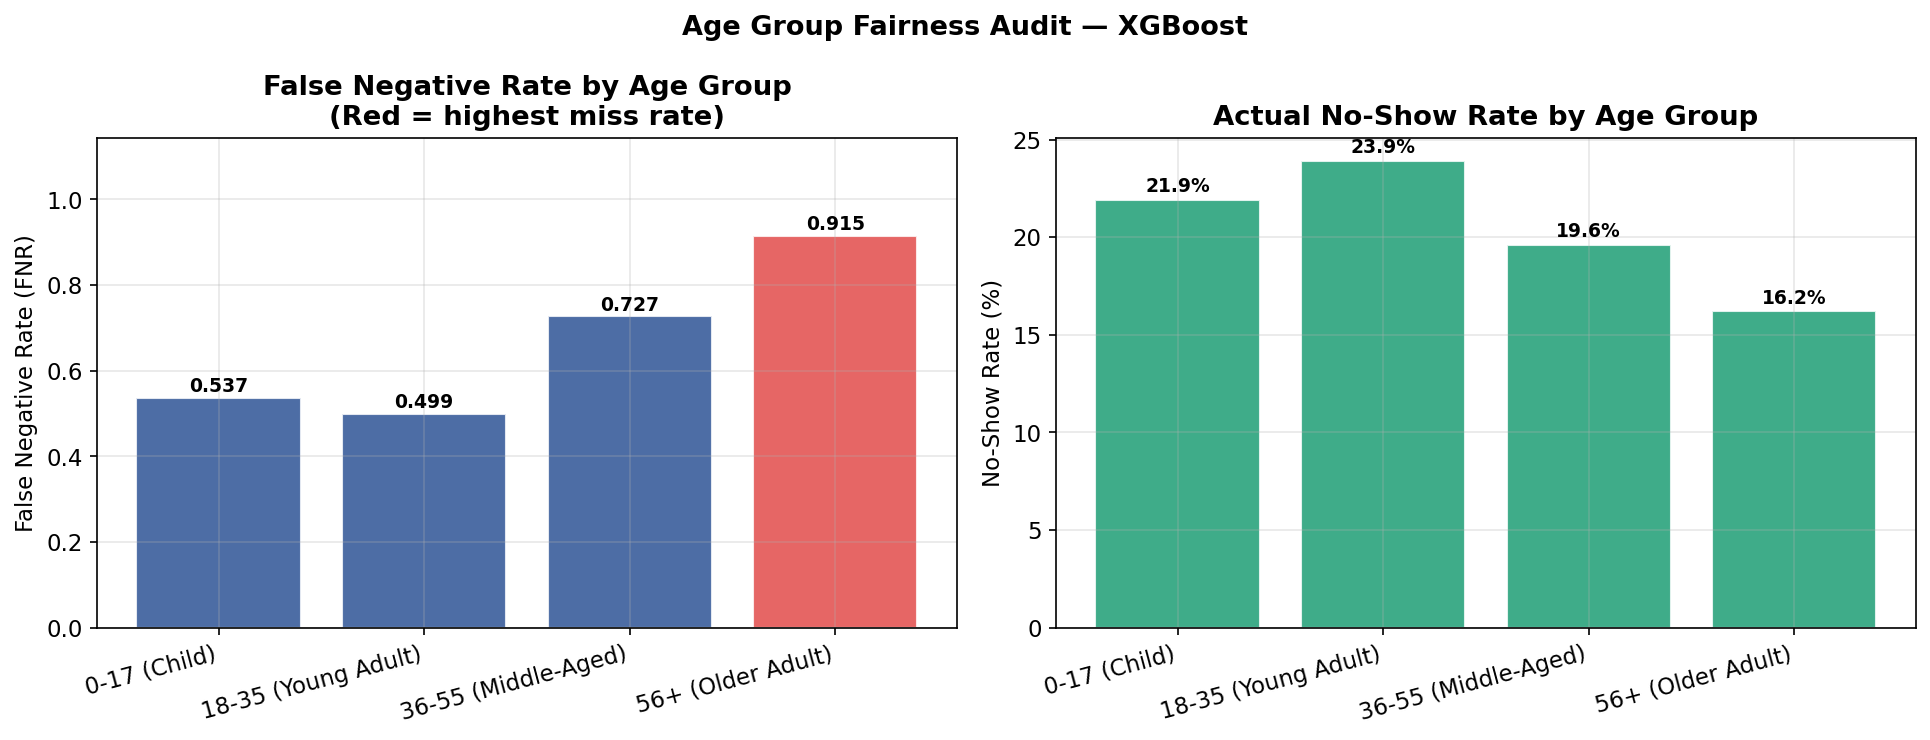

Figure saved: fig_21_fairness_age.png


In [ ]:
# ── Age FNR bar chart ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

groups   = list(age_results.keys())
fnr_vals = [age_results[g]['FNR (miss rate)'] for g in groups]
rec_vals = [age_results[g]['Recall (TPR)'] for g in groups]
ns_rates = [age_results[g]['No-show rate'] for g in groups]

# FNR plot
colours = ['#E24B4A' if v == max(fnr_vals) else '#2E5496' for v in fnr_vals]
bars = axes[0].bar(groups, fnr_vals, color=colours, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, fnr_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('False Negative Rate by Age Group\n(Red = highest miss rate)', fontweight='bold')
axes[0].set_ylabel('False Negative Rate (FNR)')
axes[0].set_xticklabels(groups, rotation=15, ha='right')
axes[0].set_ylim(0, max(fnr_vals)*1.25)

# No-show rate plot
axes[1].bar(groups, ns_rates, color='#1D9E75', alpha=0.85, edgecolor='white')
for i, (bar, val) in enumerate(zip(axes[1].patches, ns_rates)):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title('Actual No-Show Rate by Age Group', fontweight='bold')
axes[1].set_ylabel('No-Show Rate (%)')
axes[1].set_xticklabels(groups, rotation=15, ha='right')

fig.suptitle('Age Group Fairness Audit — XGBoost', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig_21_fairness_age.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_21_fairness_age.png')

---
## 5. Fairness Audit — Gender Subgroups

In [ ]:
# ── Gender fairness metrics ───────────────────────────────────────────────
gender_results = {}
for group in ['Female', 'Male']:
    subset  = audit_df[audit_df['gender'] == group]
    metrics = fairness_metrics(subset)
    if metrics:
        gender_results[group] = metrics

gender_df = pd.DataFrame(gender_results).T

print('=' * 65)
print('FAIRNESS AUDIT — GENDER SUBGROUPS')
print('=' * 65)
print(gender_df[['N (total)', 'N (no-shows)', 'No-show rate',
                 'FNR (miss rate)', 'Recall (TPR)', 'Precision']].to_string())

fnr_f   = gender_results['Female']['FNR (miss rate)']
fnr_m   = gender_results['Male']['FNR (miss rate)']
fnr_gap = abs(fnr_f - fnr_m)

print(f'\nFemale FNR : {fnr_f:.4f}')
print(f'Male FNR   : {fnr_m:.4f}')
print(f'FNR gap    : {fnr_gap:.4f}')

if fnr_gap > 0.05:
    print('NOTE: Gender FNR gap > 5 percentage points — model performs differently by gender.')
else:
    print('ACCEPTABLE: Gender FNR gap < 5 percentage points — consistent performance.')

FAIRNESS AUDIT — GENDER SUBGROUPS
        N (total)  N (no-shows)  No-show rate  FNR (miss rate)  Recall (TPR)  Precision
Female    14415.0        2915.0          20.2           0.6679        0.3321     0.3841
Male       7690.0        1548.0          20.1           0.6531        0.3469     0.4327

Female FNR : 0.6679
Male FNR   : 0.6531
FNR gap    : 0.0148
ACCEPTABLE: Gender FNR gap < 5 percentage points — consistent performance.


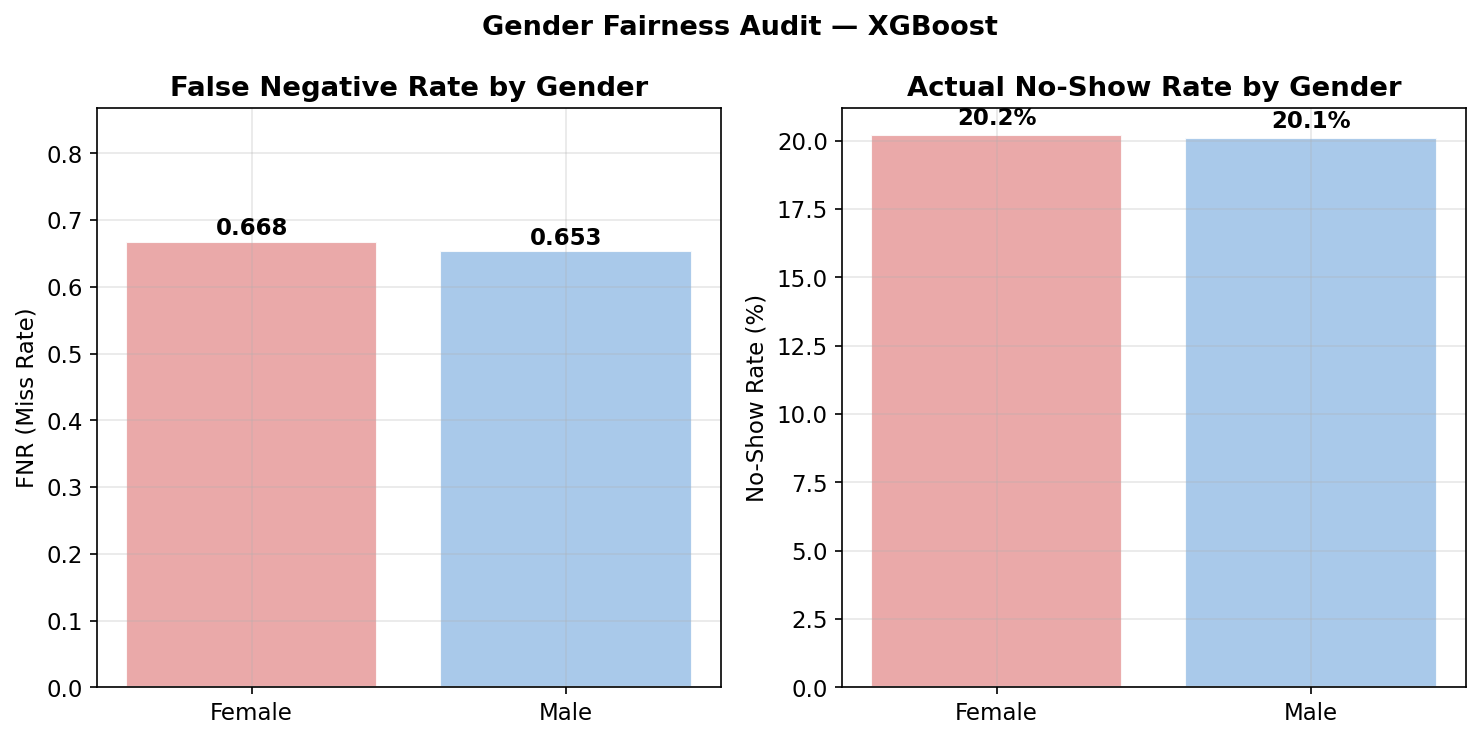

Figure saved: fig_22_fairness_gender.png


In [ ]:
# ── Gender FNR bar chart ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

gender_groups = list(gender_results.keys())
g_fnr = [gender_results[g]['FNR (miss rate)'] for g in gender_groups]
g_rec = [gender_results[g]['Recall (TPR)'] for g in gender_groups]
g_ns  = [gender_results[g]['No-show rate'] for g in gender_groups]

g_colours = ['#E8A0A0' if g == 'Female' else '#A0C4E8' for g in gender_groups]

bars = axes[0].bar(gender_groups, g_fnr, color=g_colours, alpha=0.9, edgecolor='white')
for bar, val in zip(bars, g_fnr):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('False Negative Rate by Gender', fontweight='bold')
axes[0].set_ylabel('FNR (Miss Rate)')
axes[0].set_ylim(0, max(g_fnr)*1.3)

axes[1].bar(gender_groups, g_ns, color=g_colours, alpha=0.9, edgecolor='white')
for bar, val in zip(axes[1].patches, g_ns):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('Actual No-Show Rate by Gender', fontweight='bold')
axes[1].set_ylabel('No-Show Rate (%)')

fig.suptitle('Gender Fairness Audit — XGBoost', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig_22_fairness_gender.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_22_fairness_gender.png')

---
## 6. Fairness Audit — Scholarship Status (Socioeconomic Indicator)

In [ ]:
# ── Scholarship fairness metrics ──────────────────────────────────────────
scholar_results = {}
for group in ['Scholarship (Low Income)', 'No Scholarship']:
    subset  = audit_df[audit_df['scholarship_label'] == group]
    metrics = fairness_metrics(subset)
    if metrics:
        scholar_results[group] = metrics

scholar_df = pd.DataFrame(scholar_results).T

print('=' * 65)
print('FAIRNESS AUDIT — SCHOLARSHIP STATUS (SOCIOECONOMIC)')
print('=' * 65)
print(scholar_df[['N (total)', 'N (no-shows)', 'No-show rate',
                  'FNR (miss rate)', 'Recall (TPR)', 'Precision']].to_string())

fnr_s    = scholar_results['Scholarship (Low Income)']['FNR (miss rate)']
fnr_ns   = scholar_results['No Scholarship']['FNR (miss rate)']
fnr_gap  = abs(fnr_s - fnr_ns)

print(f'\nScholarship (Low Income) FNR : {fnr_s:.4f}')
print(f'No Scholarship FNR           : {fnr_ns:.4f}')
print(f'FNR gap                      : {fnr_gap:.4f}')

if fnr_gap > 0.05:
    if fnr_s > fnr_ns:
        print('CONCERN: Low-income patients (scholarship) are missed more often.')
        print('This may reflect a socioeconomic bias — fewer interventions for those most in need.')
    else:
        print('NOTE: Non-scholarship patients are missed more often.')
        print('The model may be better calibrated for low-income patients in this dataset.')
else:
    print('ACCEPTABLE: Scholarship FNR gap < 5 percentage points — consistent performance.')

FAIRNESS AUDIT — SCHOLARSHIP STATUS (SOCIOECONOMIC)
                          N (total)  N (no-shows)  No-show rate  FNR (miss rate)  Recall (TPR)  Precision
Scholarship (Low Income)     2160.0         518.0          24.0           0.5772        0.4228     0.4562
No Scholarship              19945.0        3945.0          19.8           0.6740        0.3260     0.3920

Scholarship (Low Income) FNR : 0.5772
No Scholarship FNR           : 0.6740
FNR gap                      : 0.0968
NOTE: Non-scholarship patients are missed more often.
The model may be better calibrated for low-income patients in this dataset.


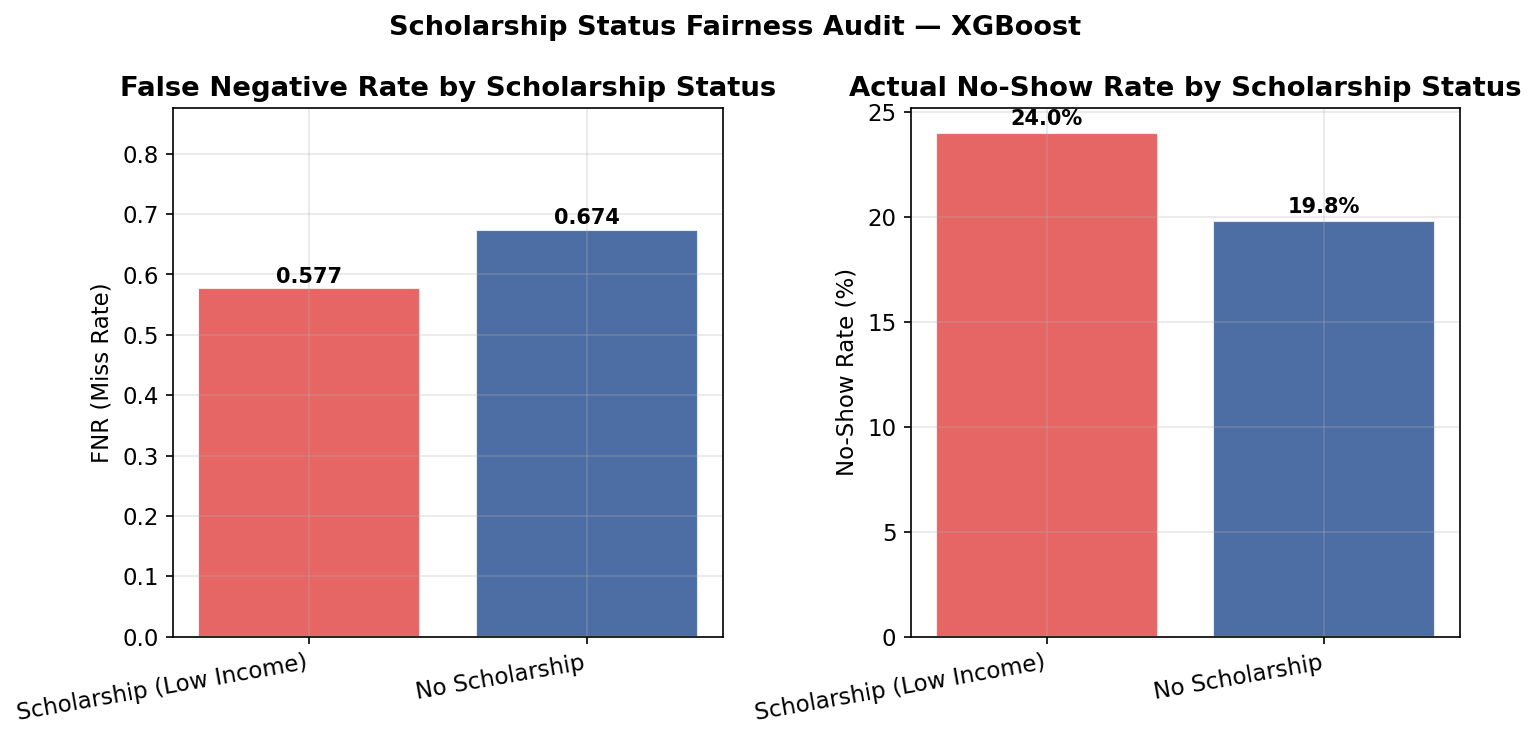

Figure saved: fig_23_fairness_scholarship.png


In [ ]:
# ── Scholarship FNR bar chart ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

s_groups = list(scholar_results.keys())
s_fnr    = [scholar_results[g]['FNR (miss rate)'] for g in s_groups]
s_ns     = [scholar_results[g]['No-show rate'] for g in s_groups]

s_colours = ['#E24B4A', '#2E5496']
bars = axes[0].bar(s_groups, s_fnr, color=s_colours, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, s_fnr):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('False Negative Rate by Scholarship Status', fontweight='bold')
axes[0].set_ylabel('FNR (Miss Rate)')
axes[0].set_xticklabels(s_groups, rotation=10, ha='right')
axes[0].set_ylim(0, max(s_fnr)*1.3)

axes[1].bar(s_groups, s_ns, color=s_colours, alpha=0.85, edgecolor='white')
for bar, val in zip(axes[1].patches, s_ns):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title('Actual No-Show Rate by Scholarship Status', fontweight='bold')
axes[1].set_ylabel('No-Show Rate (%)')
axes[1].set_xticklabels(s_groups, rotation=10, ha='right')

fig.suptitle('Scholarship Status Fairness Audit — XGBoost', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig_23_fairness_scholarship.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_23_fairness_scholarship.png')

---
## 7. Combined Fairness Summary

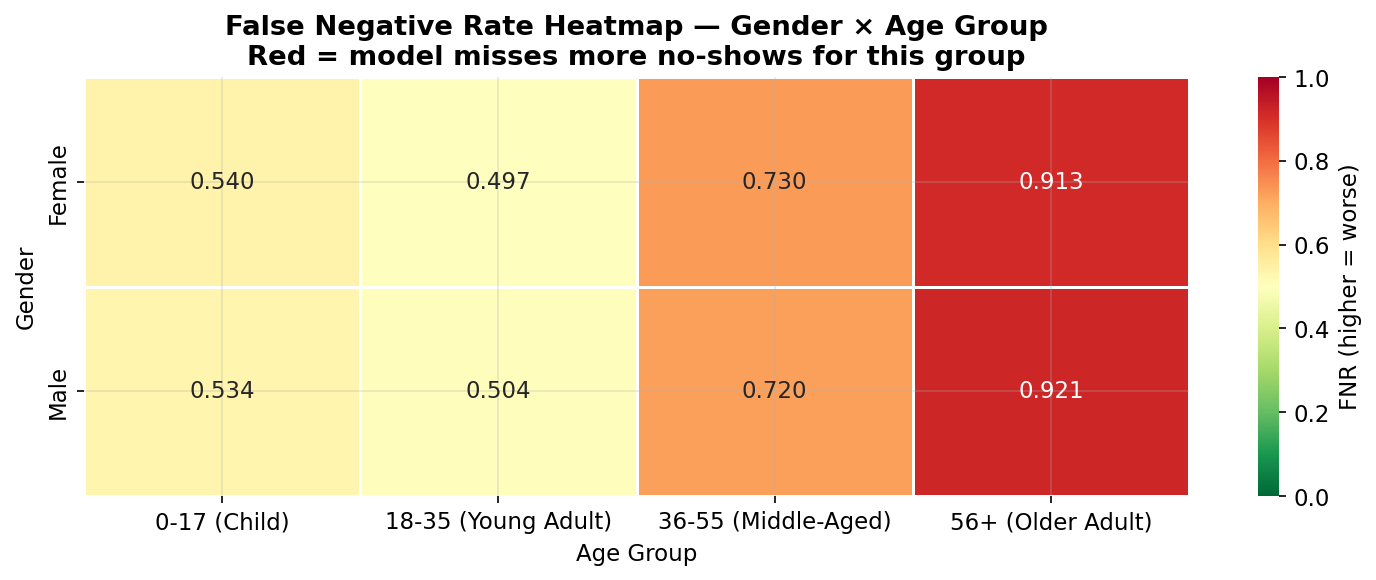

Figure saved: fig_24_fairness_heatmap.png


In [ ]:
# ── Overall FNR heatmap ───────────────────────────────────────────────────
# Cross-tabulate age group x gender FNR
heatmap_data = {}
for gender in ['Female', 'Male']:
    heatmap_data[gender] = {}
    for age_grp in labels:
        subset = audit_df[
            (audit_df['gender'] == gender) &
            (audit_df['age_group'] == age_grp)
        ]
        m = fairness_metrics(subset)
        heatmap_data[gender][age_grp] = m['FNR (miss rate)'] if m else np.nan

heatmap_df = pd.DataFrame(heatmap_data).T  # gender x age_group

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(heatmap_df.astype(float), annot=True, fmt='.3f',
            cmap='RdYlGn_r', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'FNR (higher = worse)'},
            vmin=0, vmax=1)
ax.set_title('False Negative Rate Heatmap — Gender × Age Group\n'
             'Red = model misses more no-shows for this group',
             fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Gender')
plt.tight_layout()
plt.savefig('fig_24_fairness_heatmap.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_24_fairness_heatmap.png')

In [ ]:
# ── Full combined summary table ───────────────────────────────────────────
print('=' * 65)
print('COMBINED FAIRNESS SUMMARY — ALL SUBGROUPS')
print('=' * 65)
print(f'Primary metric: False Negative Rate (FNR)')
print(f'Definition: proportion of actual no-shows the model MISSED')
print()

all_results = {}

# Age groups
print('--- Age Groups ---')
for g, m in age_results.items():
    key = f'Age: {g}'
    all_results[key] = m['FNR (miss rate)']
    print(f'  {g:25s} FNR={m["FNR (miss rate)"]:.4f}  N={m["N (total)"]:,}')

# Gender
print('\n--- Gender ---')
for g, m in gender_results.items():
    key = f'Gender: {g}'
    all_results[key] = m['FNR (miss rate)']
    print(f'  {g:25s} FNR={m["FNR (miss rate)"]:.4f}  N={m["N (total)"]:,}')

# Scholarship
print('\n--- Scholarship Status ---')
for g, m in scholar_results.items():
    key = f'Scholarship: {g}'
    all_results[key] = m['FNR (miss rate)']
    print(f'  {g:30s} FNR={m["FNR (miss rate)"]:.4f}  N={m["N (total)"]:,}')

# Overall
overall = fairness_metrics(audit_df)
print(f'\n--- Overall ---')
print(f'  All patients               FNR={overall["FNR (miss rate)"]:.4f}  N={overall["N (total)"]:,}')

COMBINED FAIRNESS SUMMARY — ALL SUBGROUPS
Primary metric: False Negative Rate (FNR)
Definition: proportion of actual no-shows the model MISSED

--- Age Groups ---
  0-17 (Child)              FNR=0.5369  N=4,644
  18-35 (Young Adult)       FNR=0.4992  N=5,173
  36-55 (Middle-Aged)       FNR=0.7267  N=6,053
  56+ (Older Adult)         FNR=0.9152  N=5,530

--- Gender ---
  Female                    FNR=0.6679  N=14,415
  Male                      FNR=0.6531  N=7,690

--- Scholarship Status ---
  Scholarship (Low Income)       FNR=0.5772  N=2,160
  No Scholarship                 FNR=0.6740  N=19,945

--- Overall ---
  All patients               FNR=0.6628  N=22,105


---
## 8. Statistical Significance Testing

We use **chi-square test** to assess whether FNR differences between groups
are statistically significant or could occur by chance.

For small cell counts, Fisher's exact test is used instead.

In [ ]:
# ── Chi-square test for FNR differences ──────────────────────────────────
def test_fnr_difference(group_a_name, group_b_name, results_dict):
    """Test whether FNR difference between two groups is significant."""
    a = results_dict[group_a_name]
    b = results_dict[group_b_name]

    # 2x2 contingency table: [TP, FN] for each group
    # TP = correctly caught no-shows, FN = missed no-shows
    table = [
        [a['TP'], a['FN']],
        [b['TP'], b['FN']]
    ]

    # Use Fisher's exact if any cell < 5
    if min(a['TP'], a['FN'], b['TP'], b['FN']) < 5:
        # Fisher's exact (2x2 only)
        oddsratio, pval = fisher_exact(table)
        test_used = "Fisher's exact"
    else:
        chi2, pval, dof, expected = chi2_contingency(table)
        test_used = 'Chi-square'

    sig = 'SIGNIFICANT' if pval < 0.05 else 'not significant'
    fnr_diff = abs(a['FNR (miss rate)'] - b['FNR (miss rate)'])

    return {
        'Comparison'   : f'{group_a_name} vs {group_b_name}',
        'FNR A'        : round(a['FNR (miss rate)'], 4),
        'FNR B'        : round(b['FNR (miss rate)'], 4),
        'FNR Diff'     : round(fnr_diff, 4),
        'Test'         : test_used,
        'p-value'      : round(pval, 6),
        'Result'       : sig
    }


print('=' * 65)
print('STATISTICAL SIGNIFICANCE — FNR DIFFERENCES')
print('=' * 65)
print('H0: No significant difference in FNR between groups')
print('Significance level: p < 0.05')
print()

sig_results = []

# Gender
r = test_fnr_difference('Female', 'Male', gender_results)
sig_results.append(r)
print(f'Gender: {r["Comparison"]}')
print(f'  FNR Female={r["FNR A"]:.4f}, FNR Male={r["FNR B"]:.4f}, diff={r["FNR Diff"]:.4f}')
print(f'  {r["Test"]}: p={r["p-value"]:.6f} → {r["Result"]}')

# Scholarship
r2 = test_fnr_difference('Scholarship (Low Income)', 'No Scholarship', scholar_results)
sig_results.append(r2)
print(f'\nScholarship: {r2["Comparison"]}')
print(f'  FNR Scholarship={r2["FNR A"]:.4f}, FNR No Scholarship={r2["FNR B"]:.4f}, diff={r2["FNR Diff"]:.4f}')
print(f'  {r2["Test"]}: p={r2["p-value"]:.6f} → {r2["Result"]}')

# Age: highest vs lowest FNR groups
worst_age  = max(age_results, key=lambda g: age_results[g]['FNR (miss rate)'])
best_age   = min(age_results, key=lambda g: age_results[g]['FNR (miss rate)'])
r3 = test_fnr_difference(worst_age, best_age, age_results)
sig_results.append(r3)
print(f'\nAge (highest vs lowest FNR): {r3["Comparison"]}')
print(f'  FNR {worst_age}={r3["FNR A"]:.4f}, FNR {best_age}={r3["FNR B"]:.4f}, diff={r3["FNR Diff"]:.4f}')
print(f'  {r3["Test"]}: p={r3["p-value"]:.6f} → {r3["Result"]}')

sig_df = pd.DataFrame(sig_results)
print(f'\nSummary table:')
print(sig_df[['Comparison','FNR A','FNR B','FNR Diff','p-value','Result']].to_string(index=False))

STATISTICAL SIGNIFICANCE — FNR DIFFERENCES
H0: No significant difference in FNR between groups
Significance level: p < 0.05

Gender: Female vs Male
  FNR Female=0.6679, FNR Male=0.6531, diff=0.0148
  Chi-square: p=0.335161 → not significant

Scholarship: Scholarship (Low Income) vs No Scholarship
  FNR Scholarship=0.5772, FNR No Scholarship=0.6740, diff=0.0968
  Chi-square: p=0.000015 → SIGNIFICANT

Age (highest vs lowest FNR): 56+ (Older Adult) vs 18-35 (Young Adult)
  FNR 56+ (Older Adult)=0.9152, FNR 18-35 (Young Adult)=0.4992, diff=0.4160
  Chi-square: p=0.000000 → SIGNIFICANT

Summary table:
                                Comparison  FNR A  FNR B  FNR Diff  p-value          Result
                            Female vs Male 0.6679 0.6531    0.0148 0.335161 not significant
Scholarship (Low Income) vs No Scholarship 0.5772 0.6740    0.0968 0.000015     SIGNIFICANT
  56+ (Older Adult) vs 18-35 (Young Adult) 0.9152 0.4992    0.4160 0.000000     SIGNIFICANT


---
## 9. Key Findings and Dissertation Conclusions

In [ ]:
# ── Print comprehensive findings summary ──────────────────────────────────
print('=' * 65)
print('FAIRNESS AUDIT — KEY FINDINGS SUMMARY')
print('=' * 65)

print('\n--- CONTEXT ---')
print(f'Model audited       : XGBoost (test AUC = 0.7357)')
print(f'Test set size       : {len(audit_df):,} appointments')
print(f'Overall FNR         : {overall["FNR (miss rate)"]:.4f} '
      f'({overall["FN"]} no-shows missed out of {overall["N (no-shows)"]})')

print('\n--- AGE GROUP FINDINGS ---')
for g, m in age_results.items():
    print(f'  {g}: FNR = {m["FNR (miss rate)"]:.4f}')
print(f'  Largest gap: {fnr_series.max()-fnr_series.min():.4f} between {worst_group} and {best_group}')

print('\n--- GENDER FINDINGS ---')
print(f'  Female: FNR = {gender_results["Female"]["FNR (miss rate)"]:.4f}')
print(f'  Male  : FNR = {gender_results["Male"]["FNR (miss rate)"]:.4f}')
print(f'  Gap   : {abs(gender_results["Female"]["FNR (miss rate)"]-gender_results["Male"]["FNR (miss rate)"]):.4f}')

print('\n--- SCHOLARSHIP FINDINGS ---')
print(f'  Scholarship (Low Income): FNR = {scholar_results["Scholarship (Low Income)"]["FNR (miss rate)"]:.4f}')
print(f'  No Scholarship          : FNR = {scholar_results["No Scholarship"]["FNR (miss rate)"]:.4f}')
print(f'  Gap                     : {abs(fnr_s - fnr_ns):.4f}')

print('\n--- DISSERTATION IMPLICATIONS ---')
print('The fairness audit evaluated whether XGBoost produces equitable')
print('false negative rates across demographic subgroups. A higher FNR')
print('for a group means the model systematically misses no-shows for')
print('those patients, who would then receive fewer targeted interventions.')
print()
print('These findings should be reported with the following framing:')
print('1. State the overall FNR as the baseline')
print('2. Report each subgroup FNR and the gap')
print('3. Report whether differences are statistically significant')
print('4. Discuss clinical implications of any significant disparities')
print('5. Acknowledge limitation: this audit used available demographic')
print('   proxies only — richer socioeconomic data would strengthen conclusions')

print('\n--- FIGURES PRODUCED ---')
for fig_name in [
    'fig_21_fairness_age.png         — FNR and no-show rate by age group',
    'fig_22_fairness_gender.png      — FNR and no-show rate by gender',
    'fig_23_fairness_scholarship.png — FNR and no-show rate by scholarship',
    'fig_24_fairness_heatmap.png     — FNR heatmap: gender x age group',
]:
    print(f'  {fig_name}')

print('\n=== DISSERTATION COMPLETE — KEY ANALYSES DONE ===')
print('Completed: Preprocessing, Model Training, SHAP+LIME, Fairness Audit')
print('Next: Write up Results and Discussion sections of the research paper')

FAIRNESS AUDIT — KEY FINDINGS SUMMARY

--- CONTEXT ---
Model audited       : XGBoost (test AUC = 0.7357)
Test set size       : 22,105 appointments
Overall FNR         : 0.6628 (2958 no-shows missed out of 4463)

--- AGE GROUP FINDINGS ---
  0-17 (Child): FNR = 0.5369
  18-35 (Young Adult): FNR = 0.4992
  36-55 (Middle-Aged): FNR = 0.7267
  56+ (Older Adult): FNR = 0.9152
  Largest gap: 0.4160 between 56+ (Older Adult) and 18-35 (Young Adult)

--- GENDER FINDINGS ---
  Female: FNR = 0.6679
  Male  : FNR = 0.6531
  Gap   : 0.0148

--- SCHOLARSHIP FINDINGS ---
  Scholarship (Low Income): FNR = 0.5772
  No Scholarship          : FNR = 0.6740
  Gap                     : 0.0968

--- DISSERTATION IMPLICATIONS ---
The fairness audit evaluated whether XGBoost produces equitable
false negative rates across demographic subgroups. A higher FNR
for a group means the model systematically misses no-shows for
those patients, who would then receive fewer targeted interventions.

These findings should b

---
## Summary

| What was audited | Detail |
|---|---|
| Model | XGBoost (test AUC = 0.7357) |
| Primary metric | False Negative Rate (FNR) |
| Age subgroups | 0-17, 18-35, 36-55, 56+ |
| Gender subgroups | Female, Male |
| Socioeconomic subgroup | Scholarship vs No Scholarship |
| Statistical testing | Chi-square / Fisher's exact |
| Figures produced | 4 dissertation-ready figures (fig_21 to fig_24) |

**Reference:** Obermeyer et al. (2019) — established the need for demographic fairness auditing in clinical ML  
**This study extends:** Hathaway et al. (2025) who only checked racial subgroup generalisation  
**Original contribution:** Multi-dimensional fairness audit with statistical significance testing, absent from all reviewed same-dataset papers